## Упражнение

- Посмотрите на данные датчика, который отслеживает атмосферный CO2 из непрерывных проб воздуха в обсерватории Мауна-Лоа на Гавайях. Эти данные включают пробы CO2 с марта 1958 года по декабрь 1980 года.

In [13]:
import pandas as pd

co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1',
                  header = 0,
                  names = ['idx', 'co2'],
                  skipfooter = 2,
                  engine='python')

# convert the column idx into a datetime object and set it as the index
co2['idx'] = pd.to_datetime(co2['idx'])
co2.set_index('idx', inplace=True)

# Rmove the name "idx" from the index column
co2.index.name = None
co2

,co2
1965-01-01,319.32
1965-02-01,320.36
1965-03-01,320.82
1965-04-01,322.06
1965-05-01,322.17
...,...
1980-08-01,337.19
1980-09-01,335.49
1980-10-01,336.63
1980-11-01,337.74


- Определите наличие основного тренда и сезонности в данных.
- Определите, являются ли данные стационарными.
- Разделите данные на обучающие (90%) и тестовые (10%).
- Найдите набор моделей-кандидатов SARIMAX, посмотрев на ACF и PACF.
- Выполните поиск по сетке для моделей-кандидатов.
- Выберите лучшие модели на основе показателей производительности, сложности модели и нормальности остатков.
- Сравните лучшую найденную вами модель с моделью из autoarima.

**Упражнение:**

Dominant Frequency: 0.083
Dominant Period: 12.00 time units
Estimated seasonal period m = 12


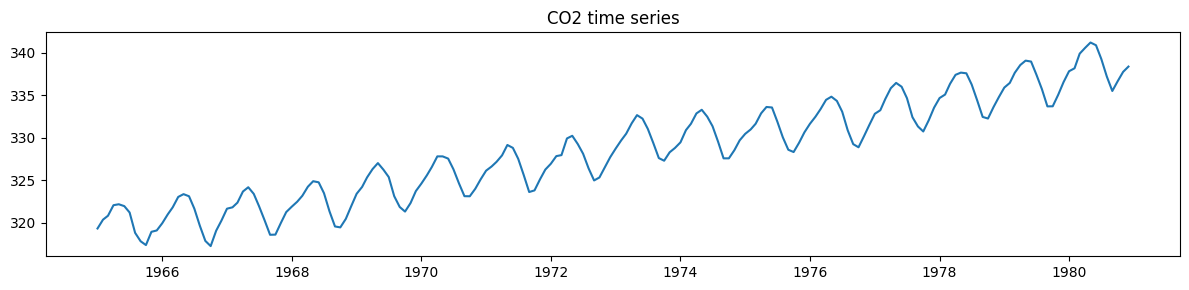

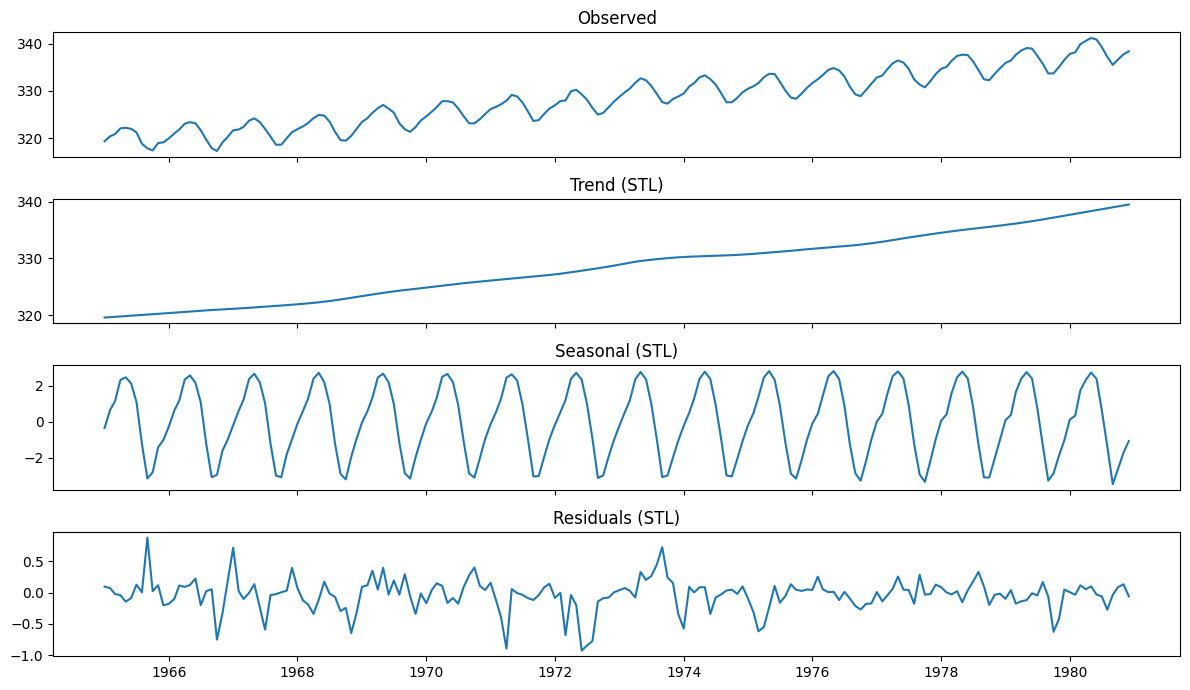

ADF p-value raw=0.9964, diff1=6.769e-05, sdiff(m)=0.05544, sdiff+diff1=8.418e-06
train= 172 test= 20
candidates p= [0, 1, 2, 4] q= [0, 1, 2, 3] P,Q in {0,1}, d,D in {0,1}

Top-5 by (MSE, AIC):
  order=(2, 0, 2), seasonal=(1, 0, 0, 12) | MSE=0.20, MAPE=0.11%, AIC=166.0, JB_p=0.000
  order=(4, 0, 2), seasonal=(1, 0, 1, 12) | MSE=0.36, MAPE=0.14%, AIC=166.5, JB_p=0.000
  order=(4, 0, 1), seasonal=(0, 1, 1, 12) | MSE=0.42, MAPE=0.15%, AIC=72.6, JB_p=0.000
  order=(2, 0, 1), seasonal=(0, 1, 1, 12) | MSE=0.43, MAPE=0.15%, AIC=70.1, JB_p=0.000
  order=(1, 0, 1), seasonal=(0, 1, 1, 12) | MSE=0.43, MAPE=0.15%, AIC=68.2, JB_p=0.000

Best SARIMAX vs auto_arima:
  best order= (2, 0, 2) seasonal= (1, 0, 0, 12) MSE=0.20 AIC=166.0 JB_p=0.000
  auto_arima order= (2, 0, 0) seasonal= (2, 1, 0, 12) MSE=0.92


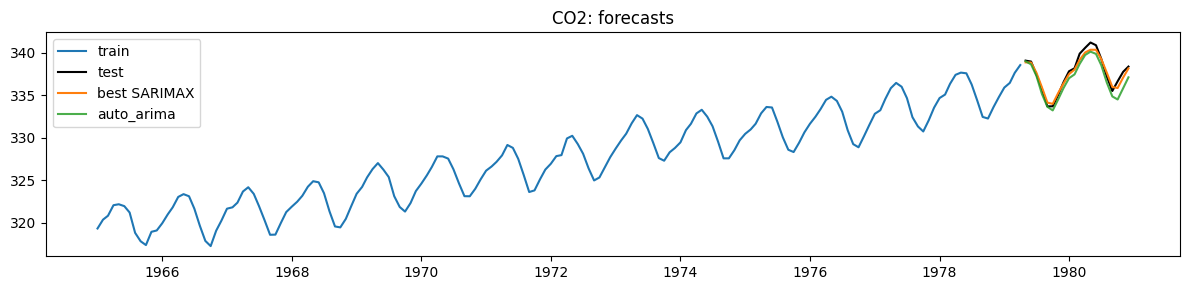

In [24]:
# SARIMAX для CO2
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from scipy.fft import fft
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX


# Игнорировать warnings
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Из лекции 1
def fft_analysis(signal):

    # Linear detrending
    slope, intercept = np.polyfit(np.arange(len(signal)), signal, 1)
    trend = np.arange(len(signal)) * slope + intercept
    detrended = signal - trend

    fft_values = fft(detrended)
    frequencies = np.fft.fftfreq(len(fft_values))

    # Remove negative frequencies and sort
    positive_frequencies = frequencies[frequencies > 0]
    magnitudes = np.abs(fft_values)[frequencies > 0]

    # Identify dominant frequency
    dominant_frequency = positive_frequencies[np.argmax(magnitudes)]
    print(f"Dominant Frequency: {dominant_frequency:.3f}")

    # Convert frequency to period (e.g., days, weeks, months, etc.)
    dominant_period = 1 / dominant_frequency
    print(f"Dominant Period: {dominant_period:.2f} time units")

    return dominant_period, positive_frequencies, magnitudes

y = co2["co2"].astype(float).copy()
y = y.interpolate(limit_direction="both")

# Тренд и сезонность
period, _, _ = fft_analysis(y.values)
m = int(round(period))
if not (2 <= m <= 60):
    m = 12
print("Estimated seasonal period m =", m)

fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(y)
ax.set_title("CO2 time series")
plt.tight_layout(); plt.show()

stl = STL(y, period=m, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
axes[0].plot(y); axes[0].set_title("Observed")
axes[1].plot(stl.trend); axes[1].set_title("Trend (STL)")
axes[2].plot(stl.seasonal); axes[2].set_title("Seasonal (STL)")
axes[3].plot(stl.resid); axes[3].set_title("Residuals (STL)")
plt.tight_layout(); plt.show()

# Стационарность (ADF)
p_raw = adfuller(y.dropna().values, autolag="AIC")[1]
p_diff1 = adfuller(np.diff(y.values), autolag="AIC")[1]
p_sdiff = adfuller(y.values[m:] - y.values[:-m], autolag="AIC")[1] if len(y) > 2 * m else np.nan
p_sdiff1 = adfuller(np.diff(y.values[m:] - y.values[:-m]), autolag="AIC")[1] if len(y) > 2 * m + 1 else np.nan
print(f"ADF p-value raw={p_raw:.4f}, diff1={p_diff1:.4g}, sdiff(m)={p_sdiff:.4g}, sdiff+diff1={p_sdiff1:.4g}")

# Train/Test split 90/10
test_size = max(1, int(np.ceil(len(y) * 0.1)))
train, test = y.iloc[:-test_size], y.iloc[-test_size:]
print("train=", len(train), "test=", len(test))

# Кандидаты по ACF/PACF (несколько первых лагов)
nlags = min(3 * m, len(train) // 2)
acf_vals, acf_ci = acf(train.values, nlags=nlags, alpha=0.05)
pacf_vals, pacf_ci = pacf(train.values, nlags=nlags, alpha=0.05)

def _sig_lags(vals, ci, max_lag=6):
    ci_half = (ci[1 : max_lag + 1, 1] - ci[1 : max_lag + 1, 0]) / 2
    centered = np.abs(vals[1 : max_lag + 1]) - ci_half
    return [i + 1 for i, v in enumerate(centered) if v > 0]

p_cand = sorted(set([0, 1, 2] + _sig_lags(pacf_vals, pacf_ci, max_lag=6)))[:4]
q_cand = sorted(set([0, 1, 2] + _sig_lags(acf_vals, acf_ci, max_lag=6)))[:4]
P_cand = [0, 1]
Q_cand = [0, 1]
d_cand = [0, 1]
D_cand = [0, 1]
print("candidates p=", p_cand, "q=", q_cand, "P,Q in {0,1}, d,D in {0,1}")

# Небольшой grid-search по SARIMAX
def _mse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.mean((a - b) ** 2))

def _mape(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    denom = np.maximum(np.abs(a), 1e-8)
    return float(np.mean(np.abs((a - b) / denom)) * 100)

results = []
for p_ in p_cand:
    for d_ in d_cand:
        for q_ in q_cand:
            for P_ in P_cand:
                for D_ in D_cand:
                    for Q_ in Q_cand:
                        order = (p_, d_, q_)
                        sorder = (P_, D_, Q_, m)
                        try:
                            mod = SARIMAX(
                                train,
                                order=order,
                                seasonal_order=sorder,
                                enforce_stationarity=False,
                                enforce_invertibility=False,
                            )
                            fit = mod.fit(disp=False)
                            fc = fit.get_forecast(steps=len(test)).predicted_mean
                            mse_v = _mse(test.values, fc.values)
                            mape_v = _mape(test.values, fc.values)
                            jb_p = float(jarque_bera(fit.resid.dropna())[1])
                            results.append((mse_v, float(fit.aic), float(fit.bic), mape_v, jb_p, order, sorder))
                        except Exception:
                            continue

if not results:
    raise RuntimeError("No SARIMAX models fitted")

results_sorted = sorted(results, key=lambda t: (t[0], t[1]))
top = results_sorted[:5]
print("\nTop-5 by (MSE, AIC):")
for mse_v, aic_v, bic_v, mape_v, jb_p, order, sorder in top:
    print(f"  order={order}, seasonal={sorder} | MSE={mse_v:.2f}, MAPE={mape_v:.2f}%, AIC={aic_v:.1f}, JB_p={jb_p:.3f}")

best_mse, best_aic, best_bic, best_mape, best_jb, best_order, best_sorder = top[0]
best_fit = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_sorder,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
best_fc = best_fit.get_forecast(steps=len(test)).predicted_mean

# Сравнение с auto_arima
auto = pm.auto_arima(
    train,
    seasonal=True,
    m=m,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=False,
)
auto_pred = pd.Series(auto.predict(n_periods=len(test)), index=test.index)
auto_mse = _mse(test.values, auto_pred.values)

print("\nBest SARIMAX vs auto_arima:")
print("  best order=", best_order, "seasonal=", best_sorder, f"MSE={best_mse:.2f}", f"AIC={best_aic:.1f}", f"JB_p={best_jb:.3f}")
print("  auto_arima order=", auto.order, "seasonal=", auto.seasonal_order, f"MSE={auto_mse:.2f}")

fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(train.index, train.values, label="train")
ax.plot(test.index, test.values, label="test", color="black")
ax.plot(test.index, best_fc.values, label="best SARIMAX")
ax.plot(test.index, auto_pred.values, label="auto_arima", alpha=0.85)
ax.set_title("CO2: forecasts")
ax.legend(); plt.tight_layout(); plt.show()
